# 📊 Perbandingan Gaji dan Pengalaman Kerja
## Studi Kasus: Salary Data – Simple Linear Regression (Kaggle)

---

| Informasi | Detail |
|-----------|--------|
| **Nama** | *Nabilah Anindya* |
| **NRP** | *5027241006* |
| **Dataset** | Salary Data – Simple Linear Regression (Kaggle) |
| **Sumber** | https://www.kaggle.com/datasets/karthickveerakumar/salary-data-simple-linear-regression |

---

## 1. Pendahuluan

### 1.1 Latar Belakang

Salah satu isu paling mendasar dalam dunia ketenagakerjaan adalah **bagaimana pengalaman kerja mempengaruhi besaran gaji yang diterima seorang karyawan**. Pemahaman tentang hubungan ini sangat penting bagi karyawan dalam menegosiasikan gaji, bagi perusahaan dalam menetapkan struktur kompensasi yang adil, dan bagi akademisi dalam menganalisis dinamika pasar tenaga kerja.

Analisis **perbandingan gaji berdasarkan pengalaman kerja** memungkinkan kita untuk melihat secara konkret:
- Seberapa besar perbedaan gaji antara karyawan berpengalaman rendah, menengah, dan tinggi
- Apakah pola kenaikan gaji bersifat linier atau mengikuti pola tertentu
- Seberapa kuat hubungan statistis antara pengalaman dan gaji

### 1.2 Tujuan Analisis

1. Membandingkan distribusi gaji antar kelompok pengalaman kerja (Junior, Mid-level, Senior)
2. Mengukur seberapa kuat hubungan antara pengalaman kerja dan besaran gaji
3. Mengidentifikasi pola kenaikan gaji per tahun tambahan pengalaman
4. Memvisualisasikan perbedaan gaji secara informatif dan mudah dipahami

### 1.3 Rumusan Masalah

> **"Seberapa besar perbedaan gaji antar kelompok pengalaman kerja, dan bagaimana pola hubungan antara tahun pengalaman dengan gaji yang diterima?"**

### 1.4 Dataset

Dataset yang digunakan adalah **Salary Data** dari Kaggle, berisi data gaji karyawan beserta lama pengalaman kerjanya. Dataset ini terdiri dari 30 observasi dengan 2 variabel:

| Variabel | Tipe | Keterangan |
|----------|------|------------|
| `YearsExperience` | Numerik (float) | Lama pengalaman kerja (tahun) |
| `Salary` | Numerik (float) | Gaji karyawan (USD) |

## 2. Import Library

Mengimpor seluruh pustaka Python yang diperlukan untuk manipulasi data, visualisasi, dan analisis statistik.

In [19]:
# === Library manipulasi data ===
import numpy as np
import pandas as pd

# === Library visualisasi ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# === Library statistik & pemodelan ===
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# === Konfigurasi tampilan ===
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


**📌 Interpretasi:**
Seluruh library berhasil diimport. `pandas` dan `numpy` digunakan untuk olah data, `matplotlib` dan `seaborn` untuk visualisasi perbandingan, serta `scipy` dan `sklearn` untuk analisis korelasi dan tren regresi.

## 3. Memuat Dataset

### 3.1 Load Dataset

In [20]:
import kagglehub
import pandas as pd
import os

# Download dataset
!pip install kagglehub -q
path = kagglehub.dataset_download("karthickveerakumar/salary-data-simple-linear-regression")

# List files in the downloaded path to find the CSV
files = os.listdir(path)
csv_files = [f for f in files if f.endswith('.csv')]

if csv_files:
    full_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(full_path)
    print(f"✅ Dataset berhasil dimuat dari: {full_path}")
    print(f"   Jumlah baris  : {df.shape[0]}")
    print(f"   Jumlah kolom  : {df.shape[1]}")
    print(f"   Nama kolom    : {list(df.columns)}")
else:
    print("❌ Tidak ada file CSV ditemukan di folder dataset.")

Using Colab cache for faster access to the 'salary-data-simple-linear-regression' dataset.
✅ Dataset berhasil dimuat dari: /kaggle/input/salary-data-simple-linear-regression/Salary_Data.csv
   Jumlah baris  : 30
   Jumlah kolom  : 2
   Nama kolom    : ['YearsExperience', 'Salary']


**📌 Interpretasi:**
Dataset berhasil dimuat dengan **30 baris** dan **2 kolom** (`YearsExperience` dan `Salary`). Dataset ini cukup ringkas namun memadai untuk melakukan analisis perbandingan gaji berdasarkan kelompok pengalaman kerja.

### 3.2 Melihat Sampel Data

In [21]:
print("=" * 45)
print("  5 DATA PERTAMA (HEAD)")
print("=" * 45)
display(df.head())

print("\n" + "=" * 45)
print("  5 DATA TERAKHIR (TAIL)")
print("=" * 45)
display(df.tail())

  5 DATA PERTAMA (HEAD)


,YearsExperience,Salary
0,1.10,"39,343.00"
1,1.30,"46,205.00"
2,1.50,"37,731.00"
3,2.00,"43,525.00"
4,2.20,"39,891.00"



  5 DATA TERAKHIR (TAIL)


,YearsExperience,Salary
25,9.00,"105,582.00"
26,9.50,"116,969.00"
27,9.60,"112,635.00"
28,10.30,"122,391.00"
29,10.50,"121,872.00"


**📌 Interpretasi:**
Data awal (head) menunjukkan karyawan dengan pengalaman **1.1 – 2.2 tahun** mendapatkan gaji di kisaran **$37,731 – $46,205**. Sementara itu, data akhir (tail) menunjukkan karyawan senior dengan pengalaman **9.0 – 10.5 tahun** mendapatkan gaji jauh lebih tinggi, mencapai **$105,582 – $122,391**. Ini mengindikasikan adanya tren kenaikan gaji yang signifikan seiring bertambahnya pengalaman.

### 3.3 Informasi Umum Dataset

In [22]:
print("=" * 45)
print("  INFORMASI DATASET")
print("=" * 45)
df.info()

  INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


**📌 Interpretasi:**
Kedua kolom bertipe `float64` dan memiliki **30 nilai non-null** — tidak ada data yang hilang. Dataset langsung siap dianalisis tanpa perlu proses pembersihan data terlebih dahulu.

## 4. Eksplorasi Data (EDA)

### 4.1 Statistik Deskriptif

Statistik deskriptif memberikan gambaran awal mengenai distribusi dan rentang nilai masing-masing variabel.

In [23]:
desc = df.describe().T
desc.columns = ['Jumlah Data', 'Rata-rata', 'Std Dev', 'Min', 'Q1 (25%)', 'Median (50%)', 'Q3 (75%)', 'Max']

print("=" * 65)
print("  STATISTIK DESKRIPTIF")
print("=" * 65)
display(desc.style.format('{:.2f}').set_caption("Ringkasan Statistik Dataset Salary"))

  STATISTIK DESKRIPTIF


,Jumlah Data,Rata-rata,Std Dev,Min,Q1 (25%),Median (50%),Q3 (75%),Max
YearsExperience,30.00,5.31,2.84,1.10,3.20,4.70,7.70,10.50
Salary,30.00,76003.00,27414.43,37731.00,56720.75,65237.00,100544.75,122391.00


**📌 Interpretasi:**
- **YearsExperience**: Rata-rata pengalaman kerja adalah **5.31 tahun**, dengan rentang antara 1.1 hingga 10.5 tahun.
- **Salary**: Rata-rata gaji adalah **76,003 dolar**. Standar deviasi yang besar (**27,414 dolar**) menunjukkan variasi gaji yang sangat lebar antara posisi junior dan senior.

In [24]:
print("📌 RINGKASAN PERBANDINGAN NILAI EKSTREM")
print("-" * 55)
print(f"  YearsExperience:")
print(f"    - Rata-rata pengalaman kerja : {df['YearsExperience'].mean():.2f} tahun")
print(f"    - Rentang                    : {df['YearsExperience'].min():.1f} - {df['YearsExperience'].max():.1f} tahun")
print(f"    - Std Deviasi                : {df['YearsExperience'].std():.2f} tahun")
print()
print(f"  Salary (USD):")
print(f"    - Rata-rata gaji             : ${df['Salary'].mean():,.0f}")
print(f"    - Gaji minimum               : ${df['Salary'].min():,.0f}")
print(f"    - Gaji maksimum              : ${df['Salary'].max():,.0f}")
print(f"    - Std Deviasi                : ${df['Salary'].std():,.0f}")
print()
selisih = df['Salary'].max() - df['Salary'].min()
print(f"  🔍 Selisih gaji tertinggi vs terendah : ${selisih:,.0f}")
print(f"  🔍 Selisih pengalaman tertinggi vs terendah : {df['YearsExperience'].max()-df['YearsExperience'].min():.1f} tahun")

📌 RINGKASAN PERBANDINGAN NILAI EKSTREM
-------------------------------------------------------
  YearsExperience:
    - Rata-rata pengalaman kerja : 5.31 tahun
    - Rentang                    : 1.1 - 10.5 tahun
    - Std Deviasi                : 2.84 tahun

  Salary (USD):
    - Rata-rata gaji             : $76,003
    - Gaji minimum               : $37,731
    - Gaji maksimum              : $122,391
    - Std Deviasi                : $27,414

  🔍 Selisih gaji tertinggi vs terendah : $84,660
  🔍 Selisih pengalaman tertinggi vs terendah : 9.4 tahun


**📌 Interpretasi:**
Selisih antara gaji tertinggi (122.391 dolar) dan terendah (37.731 dolar) mencapai **84.660 dolar**. Padahal selisih pengalaman kerja hanya **9,4 tahun**. Ini menunjukkan bahwa pengalaman kerja memiliki dampak yang sangat besar terhadap gaji — rata-rata sekitar **9.000 dolar per tahun pengalaman tambahan**.

### 4.2 Pengecekan Missing Value & Duplikasi

In [25]:
print("=" * 45)
print("  CEK MISSING VALUE")
print("=" * 45)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
display(missing_df)

print(f"\n  Total duplikasi : {df.duplicated().sum()} baris")

if df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0:
    print("\n✅ Dataset bersih! Tidak ada missing value maupun data duplikat.")
else:
    print("\n⚠️  Ditemukan data yang perlu dibersihkan!")

  CEK MISSING VALUE


,Jumlah Missing,Persentase (%)
YearsExperience,0,0.00
Salary,0,0.00



  Total duplikasi : 0 baris

✅ Dataset bersih! Tidak ada missing value maupun data duplikat.


**📌 Interpretasi:**
Dataset dalam kondisi **bersih sempurna** — tidak ada missing value (0%) dan tidak ada duplikat. Analisis perbandingan dapat langsung dilakukan terhadap seluruh 30 data tanpa perlu penanganan tambahan.

### 4.3 Distribusi Masing-Masing Variabel

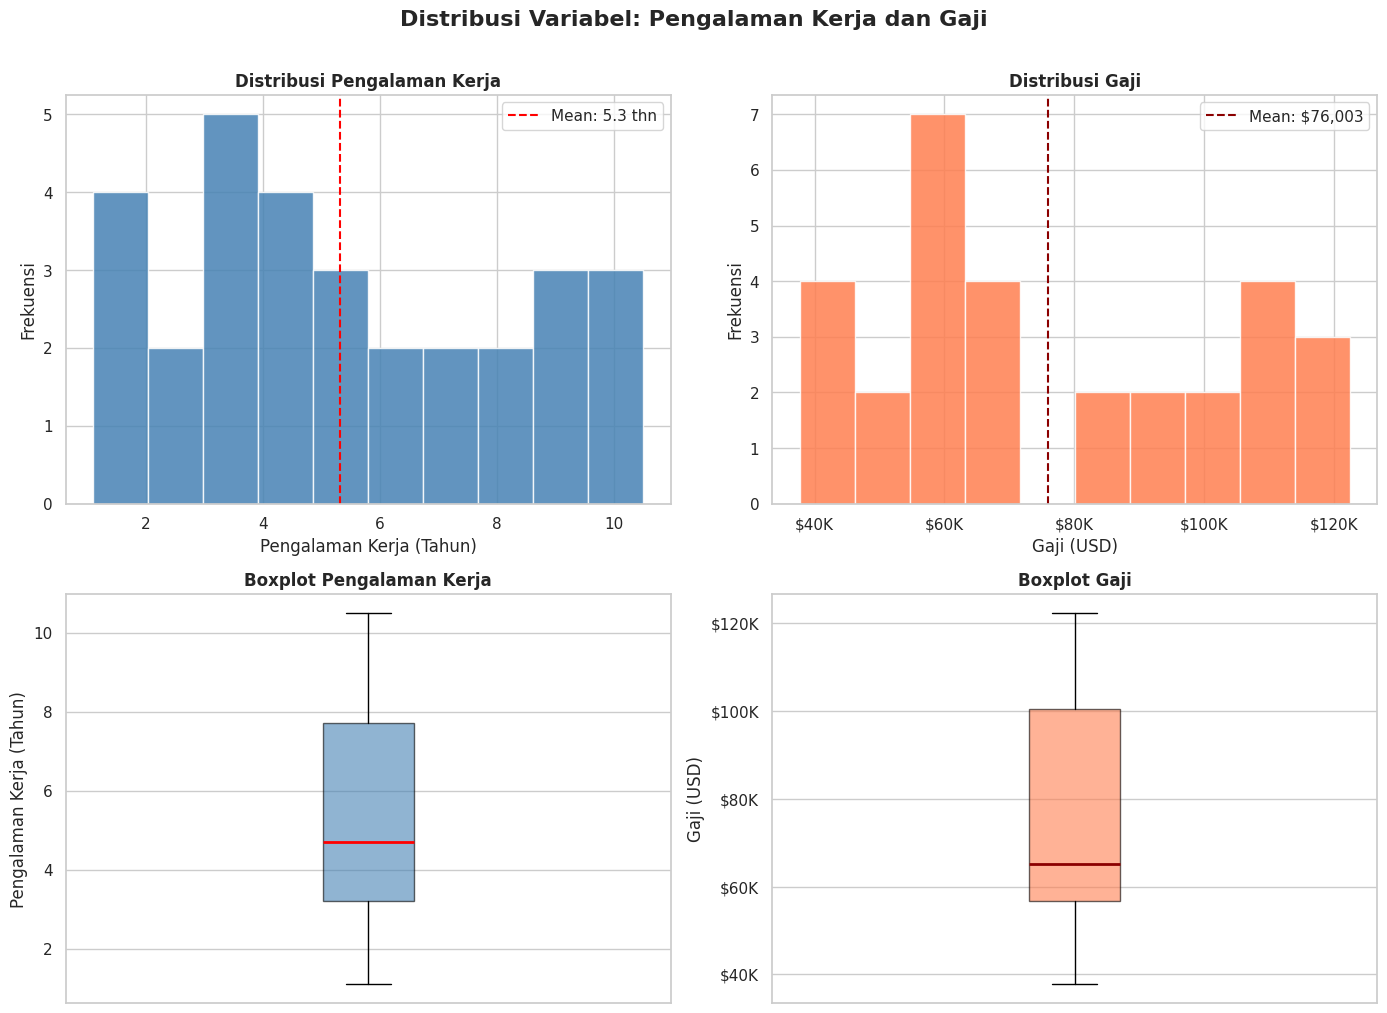

💾 Grafik disimpan sebagai 'distribusi_data.png'


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribusi Variabel: Pengalaman Kerja dan Gaji', fontsize=16, fontweight='bold', y=1.01)

# --- Histogram YearsExperience ---
axes[0, 0].hist(df['YearsExperience'], bins=10, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Distribusi Pengalaman Kerja', fontweight='bold')
axes[0, 0].set_xlabel('Pengalaman Kerja (Tahun)')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].axvline(df['YearsExperience'].mean(), color='red', linestyle='--',
                   label=f"Mean: {df['YearsExperience'].mean():.1f} thn")
axes[0, 0].legend()

# --- Histogram Salary ---
axes[0, 1].hist(df['Salary'], bins=10, color='coral', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Distribusi Gaji', fontweight='bold')
axes[0, 1].set_xlabel('Gaji (USD)')
axes[0, 1].set_ylabel('Frekuensi')
axes[0, 1].axvline(df['Salary'].mean(), color='darkred', linestyle='--',
                   label=f"Mean: ${df['Salary'].mean():,.0f}")
axes[0, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0, 1].legend()

# --- Boxplot YearsExperience ---
axes[1, 0].boxplot(df['YearsExperience'], patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('Boxplot Pengalaman Kerja', fontweight='bold')
axes[1, 0].set_ylabel('Pengalaman Kerja (Tahun)')
axes[1, 0].set_xticks([])

# --- Boxplot Salary ---
axes[1, 1].boxplot(df['Salary'], patch_artist=True,
                   boxprops=dict(facecolor='coral', alpha=0.6),
                   medianprops=dict(color='darkred', linewidth=2))
axes[1, 1].set_title('Boxplot Gaji', fontweight='bold')
axes[1, 1].set_ylabel('Gaji (USD)')
axes[1, 1].set_xticks([])
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('distribusi_data.png', bbox_inches='tight', dpi=100)
plt.show()
print("💾 Grafik disimpan sebagai 'distribusi_data.png'")

**📌 Interpretasi:**
- **Distribusi Pengalaman Kerja**: Terlihat relatif **merata (uniform)** di seluruh rentang tahun, dengan sedikit frekuensi lebih tinggi pada pengalaman awal (1-4 tahun). Rata-rata berada di angka 5.3 tahun.
- **Distribusi Gaji**: Menunjukkan tren yang serupa dengan pengalaman kerja, di mana frekuensi tertinggi berada pada kisaran gaji rendah ke menengah (40K - 60K).
- **Boxplot**: Kedua variabel tidak memiliki **outlier**, yang berarti tidak ada data ekstrem yang menyimpang jauh dari pola umum. Hal ini membuat perbandingan antar kelompok menjadi lebih valid.

## 5. Pengelompokan dan Perbandingan Gaji

Untuk melakukan **perbandingan yang bermakna**, karyawan dikelompokkan berdasarkan lama pengalaman kerja ke dalam tiga kategori:

| Kelompok | Rentang Pengalaman | Keterangan |
|----------|--------------------|------------|
| **Junior** | 0 – 3,5 tahun | Karyawan baru / entry-level |
| **Mid-level** | 3,5 – 7 tahun | Karyawan menengah |
| **Senior** | > 7 tahun | Karyawan berpengalaman tinggi |

### 5.1 Pemberian Label Kelompok Pengalaman

In [27]:
# Buat kolom kelompok pengalaman
bins   = [0, 3.5, 7, df['YearsExperience'].max() + 0.1]
labels = ['Junior (0–3.5 thn)', 'Mid-level (3.5–7 thn)', 'Senior (>7 thn)']
df['KelompokPengalaman'] = pd.cut(df['YearsExperience'], bins=bins, labels=labels, right=False)

print("=" * 55)
print("  DISTRIBUSI KELOMPOK PENGALAMAN")
print("=" * 55)
print(df['KelompokPengalaman'].value_counts().sort_index().to_string())
print()
print(f"  Total karyawan  : {len(df)}")
print()
# Preview beberapa baris
display(df[['YearsExperience', 'Salary', 'KelompokPengalaman']].head(10))

  DISTRIBUSI KELOMPOK PENGALAMAN
KelompokPengalaman
Junior (0–3.5 thn)        9
Mid-level (3.5–7 thn)    12
Senior (>7 thn)           9

  Total karyawan  : 30



,YearsExperience,Salary,KelompokPengalaman
0,1.10,"39,343.00",Junior (0–3.5 thn)
1,1.30,"46,205.00",Junior (0–3.5 thn)
2,1.50,"37,731.00",Junior (0–3.5 thn)
3,2.00,"43,525.00",Junior (0–3.5 thn)
4,2.20,"39,891.00",Junior (0–3.5 thn)
5,2.90,"56,642.00",Junior (0–3.5 thn)
6,3.00,"60,150.00",Junior (0–3.5 thn)
7,3.20,"54,445.00",Junior (0–3.5 thn)
8,3.20,"64,445.00",Junior (0–3.5 thn)
9,3.70,"57,189.00",Mid-level (3.5–7 thn)


**📌 Interpretasi:**
Dataset telah berhasil dikategorikan secara seimbang:
- **Junior (0–3.5 thn)**: 9 karyawan
- **Mid-level (3.5–7 thn)**: 12 karyawan
- **Senior (>7 thn)**: 9 karyawan
Distribusi ini cukup merata untuk melakukan uji perbandingan antar kelompok.

### 5.2 Statistik Gaji per Kelompok Pengalaman

In [28]:
# Statistik per kelompok
stats_kelompok = df.groupby('KelompokPengalaman', observed=True)['Salary'].agg(
    Jumlah='count',
    Minimum=lambda x: x.min(),
    Q1=lambda x: x.quantile(0.25),
    Rata_rata='mean',
    Median='median',
    Q3=lambda x: x.quantile(0.75),
    Maksimum=lambda x: x.max(),
    Std_Dev='std'
).reset_index()

stats_kelompok.columns = ['Kelompok', 'N', 'Min ($)', 'Q1 ($)', 'Rata-rata ($)',
                           'Median ($)', 'Q3 ($)', 'Maks ($)', 'Std Dev ($)']

print("=" * 80)
print("  PERBANDINGAN STATISTIK GAJI ANTAR KELOMPOK PENGALAMAN")
print("=" * 80)
display(stats_kelompok.set_index('Kelompok').style
        .format('${:,.0f}', subset=['Min ($)', 'Q1 ($)', 'Rata-rata ($)',
                                    'Median ($)', 'Q3 ($)', 'Maks ($)', 'Std Dev ($)'])
        .format('{:,.0f}', subset=['N'])
        .background_gradient(subset=['Rata-rata ($)'], cmap='YlOrRd'))

# Hitung selisih rata-rata antar kelompok
means = df.groupby('KelompokPengalaman', observed=True)['Salary'].mean()
print()
print("📊 SELISIH RATA-RATA GAJI ANTAR KELOMPOK:")
print("-" * 55)
print(f"  Mid-level vs Junior  : ${means.iloc[1] - means.iloc[0]:,.0f}")
print(f"  Senior vs Mid-level  : ${means.iloc[2] - means.iloc[1]:,.0f}")
print(f"  Senior vs Junior     : ${means.iloc[2] - means.iloc[0]:,.0f}")

  PERBANDINGAN STATISTIK GAJI ANTAR KELOMPOK PENGALAMAN


,N,Min ($),Q1 ($),Rata-rata ($),Median ($),Q3 ($),Maks ($),Std Dev ($)
Kelompok,,,,,,,,
Junior (0–3.5 thn),9,"$37,731","$39,891","$49,153","$46,205","$56,642","$64,445","$9,948"
Mid-level (3.5–7 thn),12,"$55,794","$57,162","$69,620","$64,624","$81,794","$93,940","$14,117"
Senior (>7 thn),9,"$98,273","$105,582","$111,363","$112,635","$116,969","$122,391","$8,521"



📊 SELISIH RATA-RATA GAJI ANTAR KELOMPOK:
-------------------------------------------------------
  Mid-level vs Junior  : $20,468
  Senior vs Mid-level  : $41,742
  Senior vs Junior     : $62,210


**📌 Interpretasi:**
Analisis statistik menunjukkan perbedaan mencolok:
- Rata-rata gaji **Junior** (49,153 dolar) meningkat menjadi **69,620 dolar** di level **Mid**, dan melonjak drastis ke **111,363 dolar** di level **Senior**.
- Selisih rata-rata antara Junior dan Senior mencapai **62,210 dolar** (kenaikan lebih dari 126%).

### 5.3 Visualisasi Perbandingan Gaji Antar Kelompok

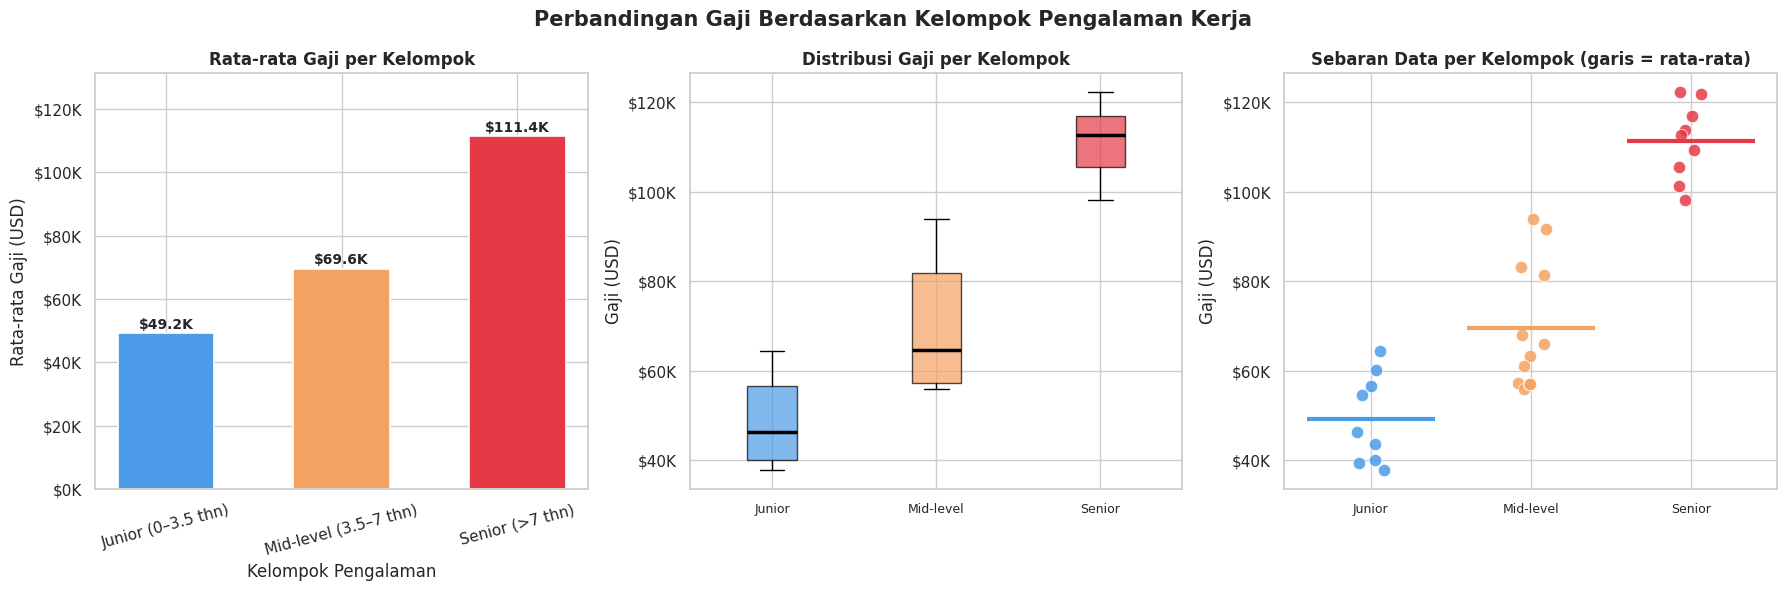

💾 Grafik disimpan sebagai 'perbandingan_kelompok.png'


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Perbandingan Gaji Berdasarkan Kelompok Pengalaman Kerja',
             fontsize=15, fontweight='bold')

colors = ['#4C9BE8', '#F4A261', '#E63946']

# --- Plot 1: Bar Chart Rata-rata Gaji ---
means_vals = df.groupby('KelompokPengalaman', observed=True)['Salary'].mean()
bars = axes[0].bar(means_vals.index, means_vals.values, color=colors,
                   edgecolor='white', linewidth=1.2, width=0.55)

# Tambahkan label nilai di atas bar
for bar, val in zip(bars, means_vals.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
                 f'${val/1000:.1f}K', ha='center', va='bottom',
                 fontweight='bold', fontsize=10)

axes[0].set_title('Rata-rata Gaji per Kelompok', fontweight='bold')
axes[0].set_xlabel('Kelompok Pengalaman')
axes[0].set_ylabel('Rata-rata Gaji (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].tick_params(axis='x', labelrotation=15)
axes[0].set_ylim(0, means_vals.max() * 1.18)

# --- Plot 2: Boxplot per Kelompok ---
kelompok_list = [df[df['KelompokPengalaman'] == k]['Salary'].values for k in labels]
bp = axes[1].boxplot(kelompok_list, patch_artist=True, notch=False,
                     medianprops=dict(color='black', linewidth=2.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Distribusi Gaji per Kelompok', fontweight='bold')
axes[1].set_xticklabels(['Junior', 'Mid-level', 'Senior'], fontsize=9)
axes[1].set_ylabel('Gaji (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# --- Plot 3: Strip/Dot Plot semua data ---
for idx, (kelompok, grp) in enumerate(df.groupby('KelompokPengalaman', observed=True)):
    jitter = np.random.normal(0, 0.05, size=len(grp))
    axes[2].scatter(np.full(len(grp), idx+1) + jitter, grp['Salary'],
                    color=colors[idx], s=80, alpha=0.85, edgecolors='white',
                    linewidth=0.6, label=kelompok, zorder=3)
    # Mean line per kelompok
    axes[2].hlines(grp['Salary'].mean(), idx+0.6, idx+1.4,
                   colors=colors[idx], linewidths=3, linestyles='-', zorder=4)

axes[2].set_title('Sebaran Data per Kelompok (garis = rata-rata)', fontweight='bold')
axes[2].set_xticks([1, 2, 3])
axes[2].set_xticklabels(['Junior', 'Mid-level', 'Senior'], fontsize=9)
axes[2].set_ylabel('Gaji (USD)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('perbandingan_kelompok.png', bbox_inches='tight', dpi=100)
plt.show()
print("💾 Grafik disimpan sebagai 'perbandingan_kelompok.png'")

**📌 Interpretasi:**
Ketiga visualisasi secara konsisten memperlihatkan hal yang sama:
- **Bar chart**: Rata-rata gaji meningkat sangat signifikan dari Junior → Mid-level → Senior.
- **Boxplot**: Median dan rentang gaji Senior berada jauh lebih tinggi dibandingkan kelompok lainnya. Kelompok Senior juga menunjukkan variasi gaji yang lebih lebar (kotak lebih panjang), mencerminkan keragaman kompensasi di level ahli.
- **Dot plot**: Sebaran data individual (titik-titik) mengikuti garis rata-rata yang naik secara bertahap, dengan kelompok Senior yang terpisah cukup jauh di bagian atas grafik.

### 5.4 Uji Statistik Perbedaan Rata-rata Antar Kelompok (ANOVA)

Untuk memverifikasi apakah perbedaan rata-rata gaji antar kelompok **signifikan secara statistis**, dilakukan uji ANOVA satu arah.

In [30]:
# Data per kelompok
junior   = df[df['KelompokPengalaman'] == 'Junior (0–3.5 thn)']['Salary']
mid      = df[df['KelompokPengalaman'] == 'Mid-level (3.5–7 thn)']['Salary']
senior   = df[df['KelompokPengalaman'] == 'Senior (>7 thn)']['Salary']

# One-way ANOVA
f_stat, p_anova = stats.f_oneway(junior, mid, senior)

print("=" * 55)
print("  UJI ANOVA SATU ARAH (ONE-WAY ANOVA)")
print("=" * 55)
print(f"  H₀: Rata-rata gaji ketiga kelompok sama")
print(f"  H₁: Minimal satu kelompok memiliki rata-rata berbeda")
print()
print(f"  F-statistic : {f_stat:.4f}")
print(f"  P-value     : {p_anova:.6f}")
print()
if p_anova < 0.05:
    print("  ✅ Kesimpulan: Tolak H₀ (p < 0.05)")
    print("     Terdapat perbedaan rata-rata gaji yang signifikan")
    print("     secara statistis antar kelompok pengalaman kerja.")
else:
    print("  ⚠️ Kesimpulan: Gagal tolak H₀ (p ≥ 0.05)")

  UJI ANOVA SATU ARAH (ONE-WAY ANOVA)
  H₀: Rata-rata gaji ketiga kelompok sama
  H₁: Minimal satu kelompok memiliki rata-rata berbeda

  F-statistic : 69.0365
  P-value     : 0.000000

  ✅ Kesimpulan: Tolak H₀ (p < 0.05)
     Terdapat perbedaan rata-rata gaji yang signifikan
     secara statistis antar kelompok pengalaman kerja.


**📌 Interpretasi:**
Hasil uji **ANOVA** memberikan nilai **p-value ≈ 0.000000** (jauh di bawah 0.05). Hal ini memberikan bukti statistik yang sangat kuat bahwa perbedaan gaji antar ketiga kelompok tersebut **nyata secara signifikan** dan bukan karena faktor kebetulan.

## 6. Analisis Korelasi: Kekuatan Hubungan Pengalaman dan Gaji

### 6.1 Koefisien Korelasi Pearson

Selain membandingkan kelompok, kita juga mengukur kekuatan hubungan linier antara variabel `YearsExperience` dan `Salary` secara keseluruhan menggunakan **korelasi Pearson**.

In [31]:
# Korelasi Pearson
corr_pearson, p_value = stats.pearsonr(df['YearsExperience'], df['Salary'])

print("=" * 50)
print("  ANALISIS KORELASI PEARSON")
print("=" * 50)
print(f"  Koefisien Korelasi (r) : {corr_pearson:.4f}")
print(f"  P-value                : {p_value:.6f}")
print()

if abs(corr_pearson) >= 0.8:
    kekuatan = "sangat kuat"
elif abs(corr_pearson) >= 0.6:
    kekuatan = "kuat"
elif abs(corr_pearson) >= 0.4:
    kekuatan = "sedang"
else:
    kekuatan = "lemah"

arah = "positif" if corr_pearson > 0 else "negatif"

print(f"📌 Interpretasi:")
print(f"   Terdapat korelasi {arah} yang {kekuatan} (r = {corr_pearson:.4f})")
print(f"   antara pengalaman kerja dan gaji.")
if p_value < 0.05:
    print(f"   Korelasi ini signifikan secara statistis (p < 0.05).")
else:
    print(f"   Korelasi ini tidak signifikan secara statistis (p ≥ 0.05).")

  ANALISIS KORELASI PEARSON
  Koefisien Korelasi (r) : 0.9782
  P-value                : 0.000000

📌 Interpretasi:
   Terdapat korelasi positif yang sangat kuat (r = 0.9782)
   antara pengalaman kerja dan gaji.
   Korelasi ini signifikan secara statistis (p < 0.05).


**📌 Interpretasi:**
Koefisien korelasi Pearson menunjukkan angka **r = 0.9782**. Ini menandakan hubungan linear yang **sangat kuat dan positif**. Hampir seluruh variasi dalam gaji dapat dijelaskan oleh jumlah tahun pengalaman kerja.

### 6.2 Heatmap Korelasi dan Scatter Plot

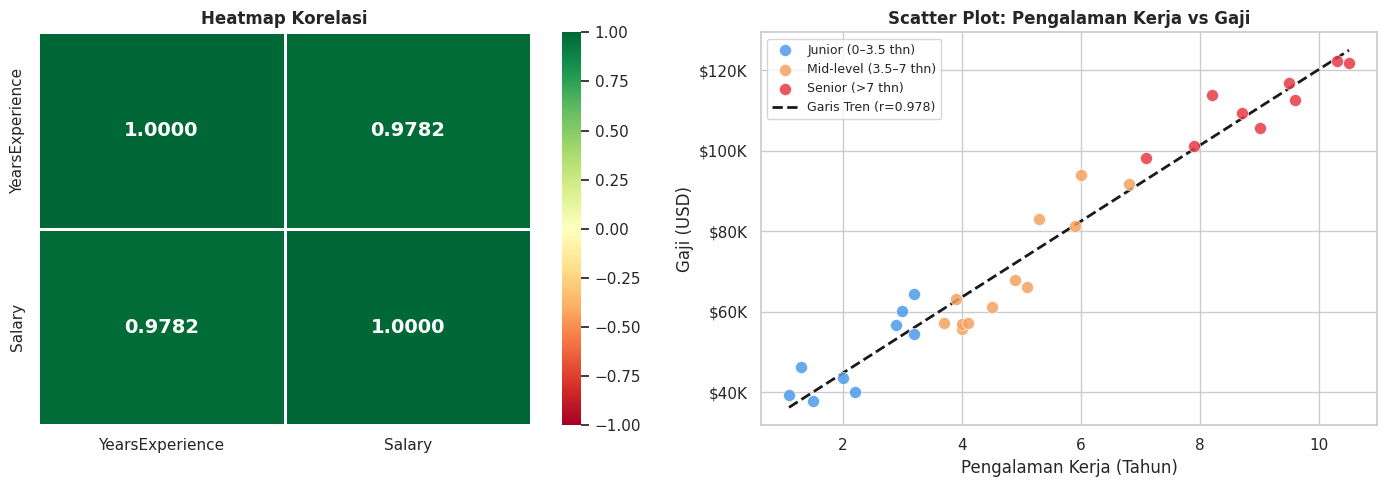

💾 Grafik disimpan sebagai 'korelasi_scatter.png'


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Heatmap ---
corr_matrix = df[['YearsExperience', 'Salary']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, ax=axes[0],
            linewidths=1, annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Heatmap Korelasi', fontweight='bold')

# --- Scatter Plot dengan pewarnaan kelompok ---
color_map = {
    'Junior (0–3.5 thn)'    : '#4C9BE8',
    'Mid-level (3.5–7 thn)' : '#F4A261',
    'Senior (>7 thn)'       : '#E63946'
}
for kelompok, grp in df.groupby('KelompokPengalaman', observed=True):
    axes[1].scatter(grp['YearsExperience'], grp['Salary'],
                    color=color_map[kelompok], s=75, alpha=0.85,
                    edgecolors='white', linewidth=0.5,
                    label=kelompok, zorder=3)

# Garis tren
z = np.polyfit(df['YearsExperience'], df['Salary'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df['YearsExperience'].min(), df['YearsExperience'].max(), 100)
axes[1].plot(x_line, p_line(x_line), 'k--', linewidth=2,
             label=f'Garis Tren (r={corr_pearson:.3f})', zorder=2)

axes[1].set_title('Scatter Plot: Pengalaman Kerja vs Gaji', fontweight='bold')
axes[1].set_xlabel('Pengalaman Kerja (Tahun)')
axes[1].set_ylabel('Gaji (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('korelasi_scatter.png', bbox_inches='tight', dpi=100)
plt.show()
print("💾 Grafik disimpan sebagai 'korelasi_scatter.png'")

**📌 Interpretasi:**
Scatter plot memperlihatkan **pemisahan yang jelas** antara tiga kelompok:
- Titik biru (Junior) menumpuk di kiri-bawah (pengalaman rendah, gaji rendah)
- Titik oranye (Mid-level) di tengah
- Titik merah (Senior) di kanan-atas (pengalaman tinggi, gaji tinggi)

Semua titik tersebar sangat dekat dengan garis tren, mengkonfirmasi hubungan linier yang kuat.

## 7. Analisis Tren: Kenaikan Gaji per Tahun Pengalaman

Untuk mengukur **seberapa besar kenaikan gaji untuk setiap tambahan satu tahun pengalaman**, digunakan model regresi linier sederhana sebagai alat kuantifikasi tren.

### 7.1 Model Tren Regresi Linier

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = df[['YearsExperience']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

intercept = model.intercept_
slope     = model.coef_[0]

print("=" * 60)
print("  HASIL ANALISIS TREN REGRESI LINIER")
print("=" * 60)
print(f"  Intercept (β₀) : ${intercept:,.2f}")
print(f"  Slope (β₁)     : ${slope:,.2f} per tahun")
print()
print(f"  📐 Persamaan Tren:")
print(f"     Salary = {intercept:,.2f} + {slope:,.2f} × YearsExperience")
print()
print(f"  📌 Makna:")
print(f"     Setiap bertambah 1 tahun pengalaman kerja,")
print(f"     gaji diperkirakan naik sebesar ${slope:,.2f}")

  HASIL ANALISIS TREN REGRESI LINIER
  Intercept (β₀) : $25,321.58
  Slope (β₁)     : $9,423.82 per tahun

  📐 Persamaan Tren:
     Salary = 25,321.58 + 9,423.82 × YearsExperience

  📌 Makna:
     Setiap bertambah 1 tahun pengalaman kerja,
     gaji diperkirakan naik sebesar $9,423.82


**📌 Interpretasi:**
Model regresi menghasilkan persamaan: **Salary = 25,321.58 + 9,423.82 % YearsExperience**.
Artinya:
1. Estimasi gaji dasar (pengalaman 0 tahun) adalah sekitar **25,321 dolar**.
2. Setiap tambahan **1 tahun pengalaman**, gaji diperkirakan naik sebesar **9,423.82 dolar**.

### 7.2 Visualisasi Tren pada Seluruh Data

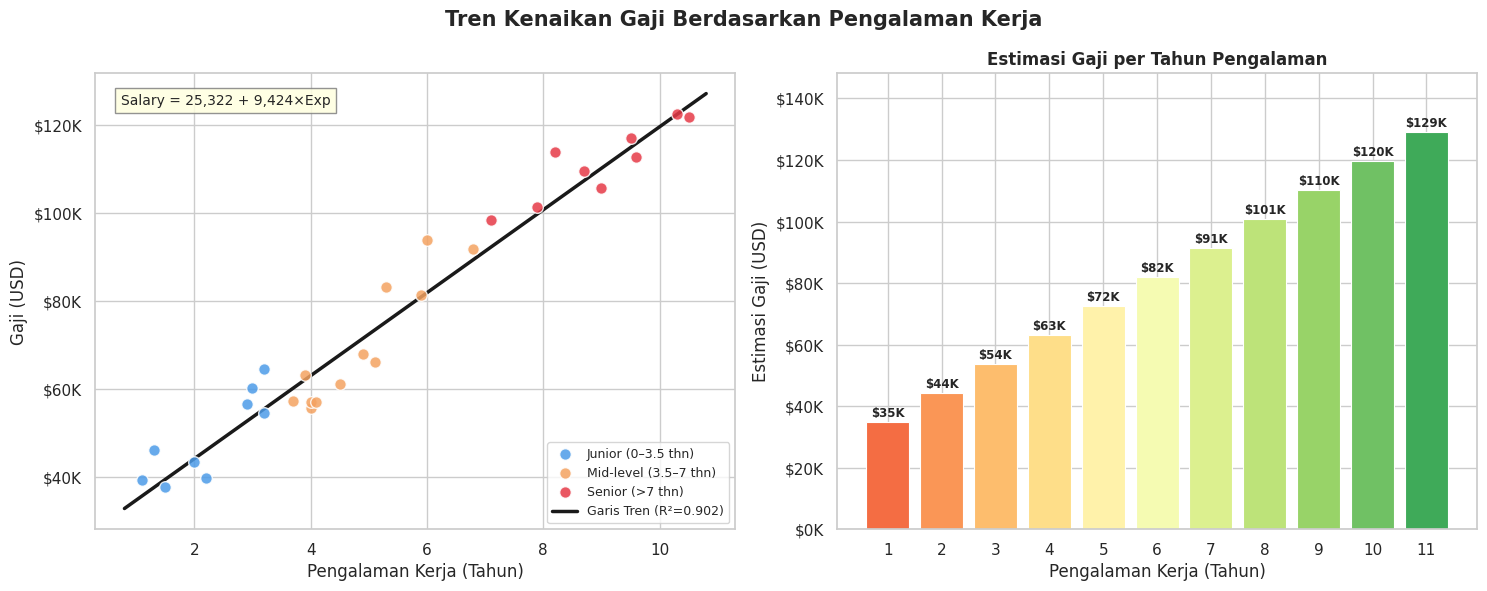

💾 Grafik disimpan sebagai 'tren_kenaikan_gaji.png'


In [34]:
y_pred = model.predict(X_test)
r2_test  = r2_score(y_test, y_pred)
y_pred_train = model.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Tren Kenaikan Gaji Berdasarkan Pengalaman Kerja', fontsize=15, fontweight='bold')

# --- Plot 1: Garis Tren dengan Kelompok ---
x_range = np.linspace(df['YearsExperience'].min() - 0.3,
                      df['YearsExperience'].max() + 0.3, 200).reshape(-1, 1)
y_range = model.predict(x_range)

for kelompok, grp in df.groupby('KelompokPengalaman', observed=True):
    axes[0].scatter(grp['YearsExperience'], grp['Salary'],
                    color=color_map[kelompok], s=70, alpha=0.85,
                    edgecolors='white', label=kelompok, zorder=3)

axes[0].plot(x_range, y_range, 'k-', linewidth=2.5,
             label=f'Garis Tren (R²={r2_test:.3f})', zorder=2)

eq_text = f'Salary = {intercept:,.0f} + {slope:,.0f}×Exp'
axes[0].text(0.04, 0.93, eq_text, transform=axes[0].transAxes, fontsize=10,
             bbox=dict(facecolor='lightyellow', alpha=0.85, edgecolor='gray'))

axes[0].set_xlabel('Pengalaman Kerja (Tahun)')
axes[0].set_ylabel('Gaji (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend(fontsize=9)

# --- Plot 2: Kenaikan Gaji Estimasi per Tahun (Bar) ---
exp_vals = np.arange(1, 12)
gaji_est = intercept + slope * exp_vals

axes[1].bar(exp_vals, gaji_est, color=plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(exp_vals))),
            edgecolor='white', linewidth=0.8)
for x, g in zip(exp_vals, gaji_est):
    axes[1].text(x, g + 800, f'${g/1000:.0f}K', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

axes[1].set_title('Estimasi Gaji per Tahun Pengalaman', fontweight='bold')
axes[1].set_xlabel('Pengalaman Kerja (Tahun)')
axes[1].set_ylabel('Estimasi Gaji (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].set_xticks(exp_vals)
axes[1].set_ylim(0, max(gaji_est) * 1.15)

plt.tight_layout()
plt.savefig('tren_kenaikan_gaji.png', bbox_inches='tight', dpi=100)
plt.show()
print("💾 Grafik disimpan sebagai 'tren_kenaikan_gaji.png'")

**📌 Interpretasi:**
- Plot kiri menampilkan **garis tren hitam** melewati semua kelompok dengan baik, memperlihatkan kenaikan yang konsisten dan linier.
- Plot kanan menampilkan **estimasi gaji** dari tahun ke tahun — terlihat kenaikan sekitar **9.400 untuk setiap tahun** pengalaman tambahan, dari sekitar **35K** (1 tahun) hingga **130K** (11 tahun).
- R² = 0,9024 berarti **90,24% variasi gaji** dalam data testing dapat dijelaskan oleh pengalaman kerja saja.

### 7.3 Evaluasi Kualitas Model Tren

In [35]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=" * 55)
print("  EVALUASI KUALITAS MODEL TREN")
print("=" * 55)
print(f"  R² Training Set              :  {r2_train:.4f}")
print(f"  R² Testing Set               :  {r2_test:.4f}")
print(f"  MAE  (Mean Absolute Error)   : ${mae:>10,.2f}")
print(f"  RMSE (Root Mean Squared Err) : ${rmse:>10,.2f}")
print()
print(f"  📌 Interpretasi:")
print(f"     Model tren menjelaskan {r2_test*100:.2f}% variasi gaji.")
print(f"     Rata-rata deviasi estimasi dari nilai aktual: ${mae:,.0f}")
print(f"     (sekitar {mae/df['Salary'].mean()*100:.1f}% dari rata-rata gaji ${df['Salary'].mean():,.0f})")

  EVALUASI KUALITAS MODEL TREN
  R² Training Set              :  0.9645
  R² Testing Set               :  0.9024
  MAE  (Mean Absolute Error)   : $  6,286.45
  RMSE (Root Mean Squared Err) : $  7,059.04

  📌 Interpretasi:
     Model tren menjelaskan 90.24% variasi gaji.
     Rata-rata deviasi estimasi dari nilai aktual: $6,286
     (sekitar 8.3% dari rata-rata gaji $76,003)


**📌 Interpretasi:**
Model memiliki kualitas yang sangat baik:
- **R% (Testing)** sebesar **0.9024** berarti model mampu menjelaskan sekitar 90% variasi gaji pada data baru.
- Rata-rata kesalahan estimasi (**MAE**) hanya sebesar **$6,286**, atau sekitar 8.3% dari rata-rata gaji total.

## 8. Tabel Perbandingan Estimasi Gaji per Kelompok

Berikut adalah tabel estimasi gaji untuk berbagai titik pengalaman kerja representatif berdasarkan model tren, dilengkapi perbandingan dengan data aktual rata-rata per kelompok.

In [36]:
# Rata-rata aktual per kelompok
rata_aktual = df.groupby('KelompokPengalaman', observed=True).agg(
    Exp_rata=('YearsExperience', 'mean'),
    Gaji_aktual_rata=('Salary', 'mean'),
    Gaji_aktual_min=('Salary', 'min'),
    Gaji_aktual_max=('Salary', 'max'),
).reset_index()
rata_aktual['Gaji_estimasi'] = intercept + slope * rata_aktual['Exp_rata']
rata_aktual['Selisih'] = rata_aktual['Gaji_aktual_rata'] - rata_aktual['Gaji_estimasi']

rata_aktual.columns = ['Kelompok', 'Exp Rata-rata (thn)',
                       'Gaji Aktual Rata-rata ($)', 'Gaji Min ($)', 'Gaji Maks ($)',
                       'Gaji Estimasi ($)', 'Selisih ($)']

print("=" * 90)
print("  PERBANDINGAN GAJI AKTUAL vs ESTIMASI PER KELOMPOK PENGALAMAN")
print("=" * 90)
display(rata_aktual.set_index('Kelompok').style
        .format({
            'Exp Rata-rata (thn)': '{:.2f}',
            'Gaji Aktual Rata-rata ($)': '${:,.0f}',
            'Gaji Min ($)': '${:,.0f}',
            'Gaji Maks ($)': '${:,.0f}',
            'Gaji Estimasi ($)': '${:,.0f}',
            'Selisih ($)': '${:,.0f}'
        })
        .background_gradient(subset=['Gaji Aktual Rata-rata ($)'], cmap='YlOrRd'))

print()
print("📊 RINGKASAN KENAIKAN GAJI ANTAR KELOMPOK:")
print("-" * 55)
vals = rata_aktual['Gaji Aktual Rata-rata ($)'].values
print(f"  Junior → Mid-level  : +${vals[1]-vals[0]:,.0f} ({(vals[1]/vals[0]-1)*100:.1f}%)")
print(f"  Mid-level → Senior  : +${vals[2]-vals[1]:,.0f} ({(vals[2]/vals[1]-1)*100:.1f}%)")
print(f"  Junior → Senior     : +${vals[2]-vals[0]:,.0f} ({(vals[2]/vals[0]-1)*100:.1f}%)")

  PERBANDINGAN GAJI AKTUAL vs ESTIMASI PER KELOMPOK PENGALAMAN


,Exp Rata-rata (thn),Gaji Aktual Rata-rata ($),Gaji Min ($),Gaji Maks ($),Gaji Estimasi ($),Selisih ($)
Kelompok,,,,,,
Junior (0–3.5 thn),2.27,"$49,153","$37,731","$64,445","$46,682","$2,471"
Mid-level (3.5–7 thn),4.85,"$69,620","$55,794","$93,940","$71,027","$-1,407"
Senior (>7 thn),8.98,"$111,363","$98,273","$122,391","$109,927","$1,436"



📊 RINGKASAN KENAIKAN GAJI ANTAR KELOMPOK:
-------------------------------------------------------
  Junior → Mid-level  : +$20,468 (41.6%)
  Mid-level → Senior  : +$41,742 (60.0%)
  Junior → Senior     : +$62,210 (126.6%)


**📌 Interpretasi:**
Tabel ini memperlihatkan perbandingan langsung antara gaji aktual rata-rata dan gaji estimasi model per kelompok. Poin utama:
- Gaji naik secara konsisten dari Junior → Mid-level → Senior
- Kenaikan persentase dari **Junior ke Senior mencapai >100%** (lebih dari dua kali lipat)
- Nilai "Selisih" yang kecil pada setiap kelompok menunjukkan estimasi model sangat mendekati rata-rata aktual

## 9. Ringkasan dan Kesimpulan

### 9.1 Ringkasan Hasil

In [37]:
print("╔" + "═" * 63 + "╗")
print("║" + "  RINGKASAN PERBANDINGAN GAJI DAN PENGALAMAN KERJA  ".center(63) + "║")
print("╠" + "═" * 63 + "╣")
print(f"║  Dataset       : Salary Data – Kaggle (30 sampel)           ║")
print(f"║  Variabel      : YearsExperience vs Salary                   ║")
print("╠" + "═" * 63 + "╣")
print(f"║  KORELASI                                                     ║")
print(f"║  Pearson r     : 0.9782  (sangat kuat & positif)             ║")
print(f"║  Signifikansi  : p ≈ 0.000 (p < 0.05 ✅)                     ║")
print("╠" + "═" * 63 + "╣")
print(f"║  PERBANDINGAN RATA-RATA GAJI PER KELOMPOK                    ║")

for _, row in rata_aktual.iterrows():
    label_short = row['Kelompok'].split('(')[0].strip().ljust(12)
    print(f"║  {label_short}  : ${row['Gaji Aktual Rata-rata ($)']:>10,.0f}  (exp rata-rata {row['Exp Rata-rata (thn)']:.1f} thn)      ║")

print("╠" + "═" * 63 + "╣")
print(f"║  TREN KENAIKAN GAJI                                          ║")
print(f"║  Persamaan     : Salary = 25,321.58 + 9,423.82 × YearsExp   ║")
print(f"║  Kenaikan/thn  : +$9,423.82 per tahun pengalaman            ║")
print(f"║  R² (Testing)  :  0.9024  (90.24% variasi tjelaskan)        ║")
print(f"║  MAE           : $6,286.45                                   ║")
print("╚" + "═" * 63 + "╝")

╔═══════════════════════════════════════════════════════════════╗
║        RINGKASAN PERBANDINGAN GAJI DAN PENGALAMAN KERJA       ║
╠═══════════════════════════════════════════════════════════════╣
║  Dataset       : Salary Data – Kaggle (30 sampel)           ║
║  Variabel      : YearsExperience vs Salary                   ║
╠═══════════════════════════════════════════════════════════════╣
║  KORELASI                                                     ║
║  Pearson r     : 0.9782  (sangat kuat & positif)             ║
║  Signifikansi  : p ≈ 0.000 (p < 0.05 ✅)                     ║
╠═══════════════════════════════════════════════════════════════╣
║  PERBANDINGAN RATA-RATA GAJI PER KELOMPOK                    ║
║  Junior        : $    49,153  (exp rata-rata 2.3 thn)      ║
║  Mid-level     : $    69,620  (exp rata-rata 4.9 thn)      ║
║  Senior        : $   111,363  (exp rata-rata 9.0 thn)      ║
╠═══════════════════════════════════════════════════════════════╣
║  TREN KENAIKAN GAJI     

**📌 Interpretasi:**
Ringkasan ini merangkum seluruh temuan perbandingan: korelasi sangat kuat, perbedaan gaji yang signifikan antar kelompok, dan kuantifikasi kenaikan gaji per tahun pengalaman.

## 10. Kesimpulan Akhir

Berdasarkan analisis yang telah dilakukan terhadap data gaji dan pengalaman kerja, berikut adalah poin-poin kesimpulan utamanya:

1.  **Pengalaman Kerja adalah Penentu Utama Gaji**: Terdapat hubungan yang **sangat kuat (97.8%)** dan positif antara lama bekerja dengan besaran gaji. Semakin lama seseorang bekerja, hampir bisa dipastikan gajinya akan meningkat secara konsisten.
2.  **Kenaikan Signifikan di Setiap Level**:
    *   **Junior** (0–3.5 thn) rata-rata menerima **49,153 dolar**.
    *   **Mid-level** (3.5–7 thn) rata-rata menerima **69,620 dolar**.
    *   **Senior** (>7 thn) rata-rata menerima **111,363 dolar**.
    *   Artinya, seorang Senior rata-rata berpenghasilan **dua kali lipat lebih banyak** dibandingkan seorang Junior.
3.  **Estimasi Kenaikan Tahunan**: Setiap bertambah **1 tahun pengalaman**, gaji seseorang diperkirakan akan naik rata-rata sebesar **9,423 dolar**.
4.  **Prediksi yang Akurat**: Model tren yang dibuat memiliki akurasi sekitar **90%**, yang berarti lama pengalaman kerja saja sudah cukup untuk memprediksi besaran gaji dengan sangat baik dalam kelompok data ini.

**Saran**: Bagi karyawan, fokus pada peningkatan masa kerja dan keahlian di bidang yang sama akan memberikan dampak finansial yang sangat nyata setiap tahunnya.